In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
!pip install tensorflow-text==2.17.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 51.2 MB/s eta 0:00:00


In [ ]:
import os


os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [ ]:
import tensorflow as tf
print(tf.__version__)


2.17.1


In [ ]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px

from numpy import newaxis
from wordcloud import WordCloud, STOPWORDS

from tqdm import tqdm

from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords

import xgboost as xgb
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional, Activation, GRU, BatchNormalization
from tensorflow.keras.layers import GlobalMaxPooling1D, Conv1D, MaxPooling1D, Flatten, Bidirectional, SpatialDropout1D
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing import sequence, text
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.optimizers import Adam

%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

plt.rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42

nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
tf.test.gpu_device_name()

''

In [ ]:
tf.__version__, hub.__version__, tensorflow_text.__version__

('2.17.1', '0.16.1', '2.17.0')

In [ ]:
!pip freeze | grep hub
!pip freeze | grep tensorflow_text
!pip freeze | grep keras
!pip freeze | grep scikit-learn

en-core-web-sm @ https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl#sha256=86cc141f63942d4b2c5fcee06630fd6f904788d2f0ab005cce45aadb8fb73889
huggingface-hub==0.26.3
kagglehub==0.3.4
tensorflow-hub==0.16.1
keras==3.5.0
tf_keras==2.17.0
scikit-learn==1.5.2


**Load HUB Model**

**USE(Universal Sentence Encoder)**

In [ ]:
module_url = 'https://tfhub.dev/google/universal-sentence-encoder-multilingual-large/3'
use = hub.load(module_url)

**Sample Text Embedding With USE**

In [ ]:
txt_1 = ["the bedroom is cozy"]
txt_2 = ["comfortable bedroom"]

In [ ]:
emb_1 = use(txt_1)
emb_2 = use(txt_2)

**Embedding Dimension**

In [ ]:
print(emb_1.shape)

(1, 512)


In [ ]:
print(np.inner(emb_1, emb_2).flatten()[0])

0.84672713


**EDA**

In [ ]:
df_hotel_reviews = pd.read_csv("Hotel_Reviews.csv")
df_hotel_reviews.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [ ]:
df_hotel_reviews.columns.tolist()

['Hotel_Address',
 'Additional_Number_of_Scoring',
 'Review_Date',
 'Average_Score',
 'Hotel_Name',
 'Reviewer_Nationality',
 'Negative_Review',
 'Review_Total_Negative_Word_Counts',
 'Total_Number_of_Reviews',
 'Positive_Review',
 'Review_Total_Positive_Word_Counts',
 'Total_Number_of_Reviews_Reviewer_Has_Given',
 'Reviewer_Score',
 'Tags',
 'days_since_review',
 'lat',
 'lng']

In [ ]:
df_hotel_reviews.describe().T

,count,mean,std,min,25%,50%,75%,max
Additional_Number_of_Scoring,515738.0,498.081836,500.538467,1.000000,169.000000,341.000000,660.000000,2682.000000
Average_Score,515738.0,8.397487,0.548048,5.200000,8.100000,8.400000,8.800000,9.800000
Review_Total_Negative_Word_Counts,515738.0,18.539450,29.690831,0.000000,2.000000,9.000000,23.000000,408.000000
Total_Number_of_Reviews,515738.0,2743.743944,2317.464868,43.000000,1161.000000,2134.000000,3613.000000,16670.000000
Review_Total_Positive_Word_Counts,515738.0,17.776458,21.804185,0.000000,5.000000,11.000000,22.000000,395.000000
Total_Number_of_Reviews_Reviewer_Has_Given,515738.0,7.166001,11.040228,1.000000,1.000000,3.000000,8.000000,355.000000
Reviewer_Score,515738.0,8.395077,1.637856,2.500000,7.500000,8.800000,9.600000,10.000000
lat,512470.0,49.442439,3.466325,41.328376,48.214662,51.499981,51.516288,52.400181
lng,512470.0,2.823803,4.579425,-0.369758,-0.143372,0.010607,4.834443,16.429233


In [ ]:
df_hotel_reviews.describe(include='object').T

,count,unique,top,freq
Hotel_Address,515738,1493,163 Marsh Wall Docklands Tower Hamlets London ...,4789
Review_Date,515738,731,8/2/2017,2585
Hotel_Name,515738,1492,Britannia International Hotel Canary Wharf,4789
Reviewer_Nationality,515738,227,United Kingdom,245246
Negative_Review,515738,330011,No Negative,127890
Positive_Review,515738,412601,No Positive,35946
Tags,515738,55242,"[' Leisure trip ', ' Couple ', ' Double Room '...",5101
days_since_review,515738,731,1 days,2585


**Review Score**

In [ ]:
df_hotel_reviews.Reviewer_Score.describe().T

,Reviewer_Score
count,515738.000000
mean,8.395077
std,1.637856
min,2.500000
25%,7.500000
50%,8.800000
75%,9.600000
max,10.000000


In [ ]:
fig = px.histogram(df_hotel_reviews, x="Reviewer_Score", title='Review Score Distribution', nbins=20, text_auto=True)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

**Review Sentiment Distribution**

In [ ]:
print(f"Total Positive word count {df_hotel_reviews.Review_Total_Positive_Word_Counts.sum()}, Total negative word count {df_hotel_reviews.Review_Total_Negative_Word_Counts.sum()}")

Total Positive word count 9167995, Total negative word count 9561499


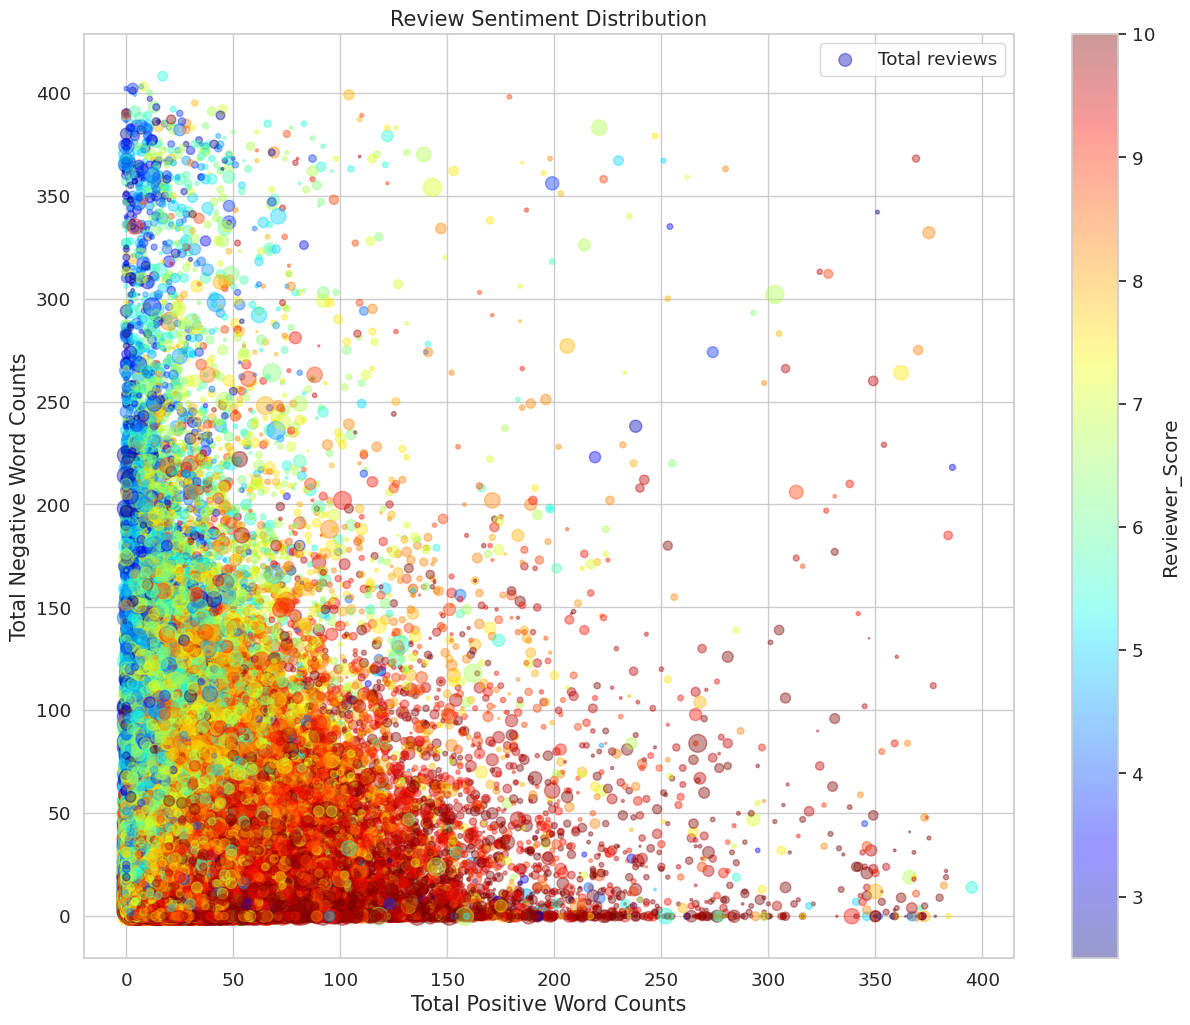

In [ ]:
df_hotel_reviews.plot(kind='scatter',
                      x='Review_Total_Positive_Word_Counts',
                      y='Review_Total_Negative_Word_Counts',
                      label='Total reviews',
             s=df_hotel_reviews.Total_Number_of_Reviews/100,
             c='Reviewer_Score',
             cmap=plt.get_cmap('jet'),
             colorbar=True,
             alpha=0.4, figsize=(15,12),
             sharex=False,
             )
font_size = 15
plt.title("Review Sentiment Distribution",  fontsize=font_size)
plt.xlabel("Total Positive Word Counts", fontsize=font_size)
plt.ylabel("Total Negative Word Counts",  fontsize=font_size)
plt.legend()
plt.show()

**Reviewer Nationality**

In [ ]:
# Top 20
df_hotel_reviews.Reviewer_Nationality.value_counts()[:20]

,count
Reviewer_Nationality,
United Kingdom,245246
United States of America,35437
Australia,21686
Ireland,14827
United Arab Emirates,10235
Saudi Arabia,8951
Netherlands,8772
Switzerland,8678
Germany,7941


In [ ]:
fig = px.histogram(df_hotel_reviews, x="Average_Score", title='Review Average Score Distribution')
fig.show()

**Positive Vs Negative Word Count Aong Hotel Reviews**

In [ ]:
px.histogram(x=abs(df_hotel_reviews.Review_Total_Positive_Word_Counts - df_hotel_reviews.Review_Total_Negative_Word_Counts), title='Difference Between Total Positive and Negative Word Count Among Hotel Reviews')

**Data Preprocessing**

**Cleaning Review Text**

In [ ]:
# outliers
df_hotel_reviews['Negative_Review'][1]

'No Negative'

In [ ]:
df_hotel_reviews.loc[:, 'Positive_Review'] = df_hotel_reviews.Positive_Review.apply(lambda x: x.replace('No Positive', ''))
df_hotel_reviews.loc[:, 'Negative_Review'] = df_hotel_reviews.Negative_Review.apply(lambda x: x.replace('No Negative', ''))

In [ ]:
df_hotel_reviews['Negative_Review'][1]

''

**Merge Feature (Both Review Text)**

In [ ]:
df_hotel_reviews['review'] = df_hotel_reviews.Positive_Review + df_hotel_reviews.Negative_Review

**Set Sentiment Type**

Setting the sentiment threshold to 7, everything is negative below 7

In [ ]:
df_hotel_reviews["review_type"]=df_hotel_reviews["Reviewer_Score"].apply(lambda x: "bad" if x < 7 else "good")

In [ ]:
df_reviews=df_hotel_reviews[["review", "review_type"]]

**Final Preprocessed Dataset**

In [ ]:
df_reviews

,review,review_type
0,Only the park outside of the hotel was beauti...,bad
1,No real complaints the hotel was great great ...,good
2,Location was good and staff were ok It is cut...,good
3,Great location in nice surroundings the bar a...,bad
4,Amazing location and building Romantic settin...,bad
...,...,...
515733,location no trolly or staff to help you take ...,good
515734,Breakfast was ok and we got earlier check in ...,bad
515735,The ac was useless It was a hot week in vienn...,bad
515736,The rooms are enormous and really comfortable...,good


**Review Type Distribution**

In [ ]:
fig = px.histogram(df_reviews, x="review_type", title='Review Type Distribution', text_auto=True)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df_reviews[df_reviews.review_type == 'good'].review.value_counts()

,count
review,
Location,947
Everything Nothing,938
Everything,599
Great location,253
Everything,219
...,...
the hotel is so close to Covent Garden shopes but in particular Restaurant and bar pub the hotel is in a closed street thus the taxi is not stopping exactly in front of the hotel but at 30 meters,1
Lovely cosy feel Great extras that you would expect from a much more expensive hotel in the way of toiletries slippers etc Quiet location but we did stay on a Monday night Brilliant for getting to many of the theatres Contrary to many of the reviews I found the service disappointingly impersonal for such a small hotel The luggage storage facility was great but is not locked I could basically have popped back in walked out with anyone s case when I returned later in the day,1
Cleanliness of room and en suite very good standard Staff very friendly and helpful Good location for theatres and restaurants Hall and stair area very tired Carpet needs replacing Didn t like being on 3rd floor with no lift,1


In [ ]:
good_reviews = df_reviews[df_reviews.review_type == "good"]
bad_reviews = df_reviews[df_reviews.review_type == "bad"]

**Word Cloud**

In [ ]:
good_reviews_text = " ".join(good_reviews.review.to_numpy().tolist())
bad_reviews_text = " ".join(bad_reviews.review.to_numpy().tolist())

In [ ]:
# generate Word Cloud
def gen_wc(txt):
  stopwords = set(STOPWORDS)
  wc = WordCloud(width=800, height=400,background_color="white", max_font_size=300, stopwords = stopwords).generate(txt)
  plt.figure(figsize=(14,10))
  plt.imshow(wc, interpolation="bilinear")
  plt.axis('off')
  plt.show()


**Good Reviews**

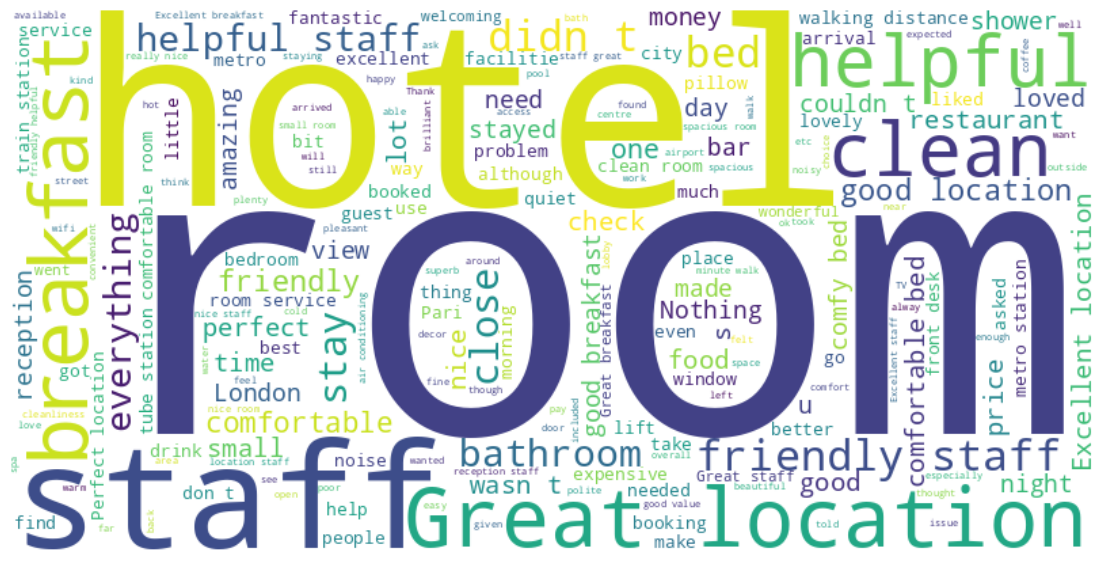

In [ ]:
gen_wc(good_reviews_text)

**Bad Reviews**

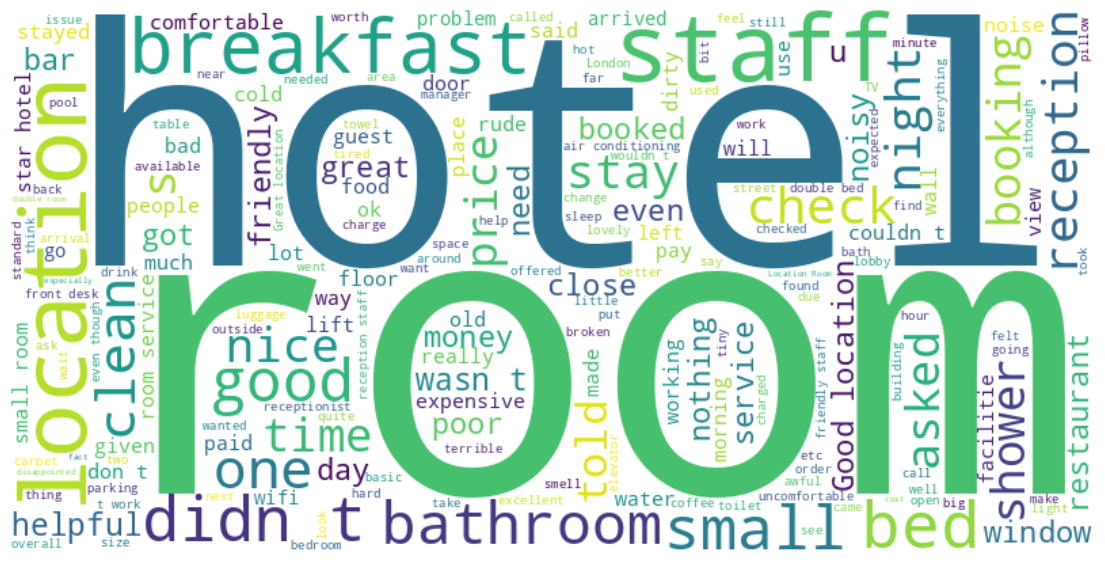

In [ ]:
gen_wc(bad_reviews_text)

**Resample Dataset**

Under sample the positive review to achieve a balanced distribution between reviews

In [ ]:
good_df = good_reviews.sample(n=len(bad_reviews), random_state=RANDOM_SEED)

df_review_resampled = pd.concat([good_df, bad_reviews], ignore_index=True)
df_review_resampled.shape

(173702, 2)

In [ ]:
df_review_resampled.head()

,review,review_type
0,Location was excellent rooms were extremely c...,good
1,very comfortable bed excellent air con great ...,good
2,The views,good
3,Clean and comfortable room Kettle and selecti...,good
4,Beds comfy staff lovely food amazing room spa...,good


**After Resampled**

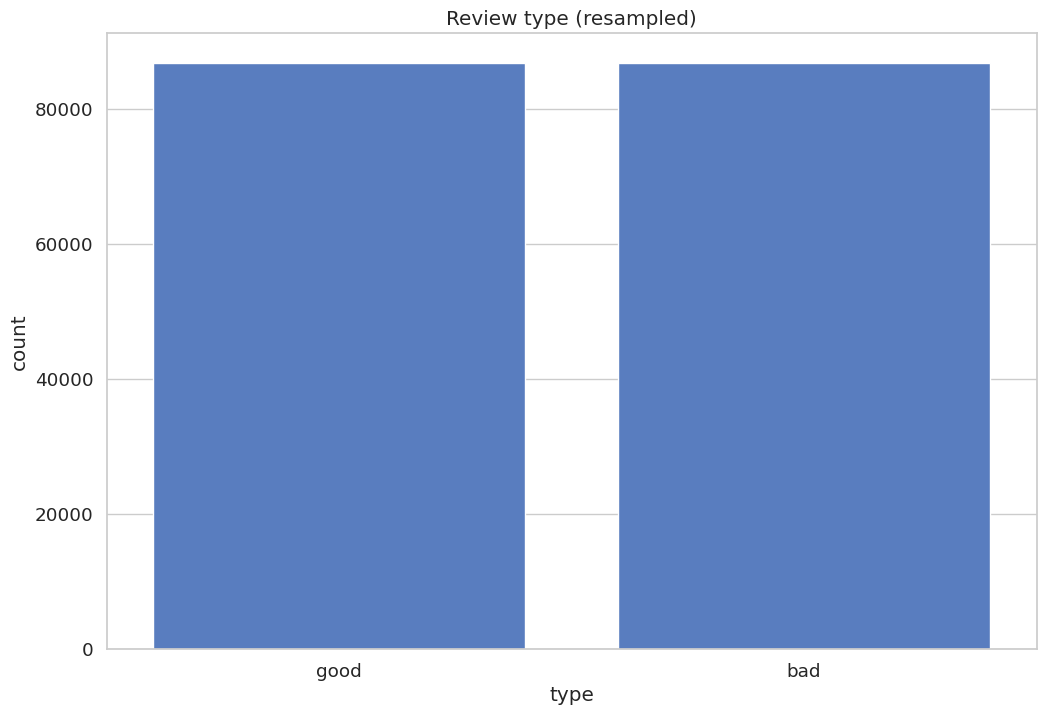

In [ ]:
sns.countplot(
  x='review_type',
  data=df_review_resampled,
  order=df_review_resampled.review_type.value_counts().index
)

plt.xlabel("type")
plt.title("Review type (resampled)");

**Data Preparation**

Encoding Labels

In [ ]:
# one_hot_encoder = preprocessing.OneHotEncoder(sparse=False)
# encoded_review = one_hot_encoder.fit_transform(df_review_resampled.review_type.to_numpy().reshape(-1, 1))


label_enc = preprocessing.LabelEncoder()
encoded_review = label_enc.fit_transform(df_review_resampled.review_type.values)

train / test split

In [ ]:
train_reviews, test_reviews, y_train, y_test = train_test_split(
    df_review_resampled.review,
    encoded_review,
    test_size=0.25,
    random_state=RANDOM_SEED
  )

**Modeling**

**Feature Enginnering**

TF-IDF

In [ ]:
%%time
tfv = TfidfVectorizer(min_df=3,  max_features=None,
            strip_accents='unicode', analyzer='word',token_pattern=r'\w{1,}',
            ngram_range=(1, 3), use_idf=True, smooth_idf=True, sublinear_tf=True,
            stop_words='english')

tfv.fit(list(train_reviews) + list(test_reviews))

X_train_tfv = tfv.transform(train_reviews)
X_test_tfv = tfv.transform(test_reviews)


CPU times: user 34.8 s, sys: 1.08 s, total: 35.8 s
Wall time: 36.3 s


LSA Plot

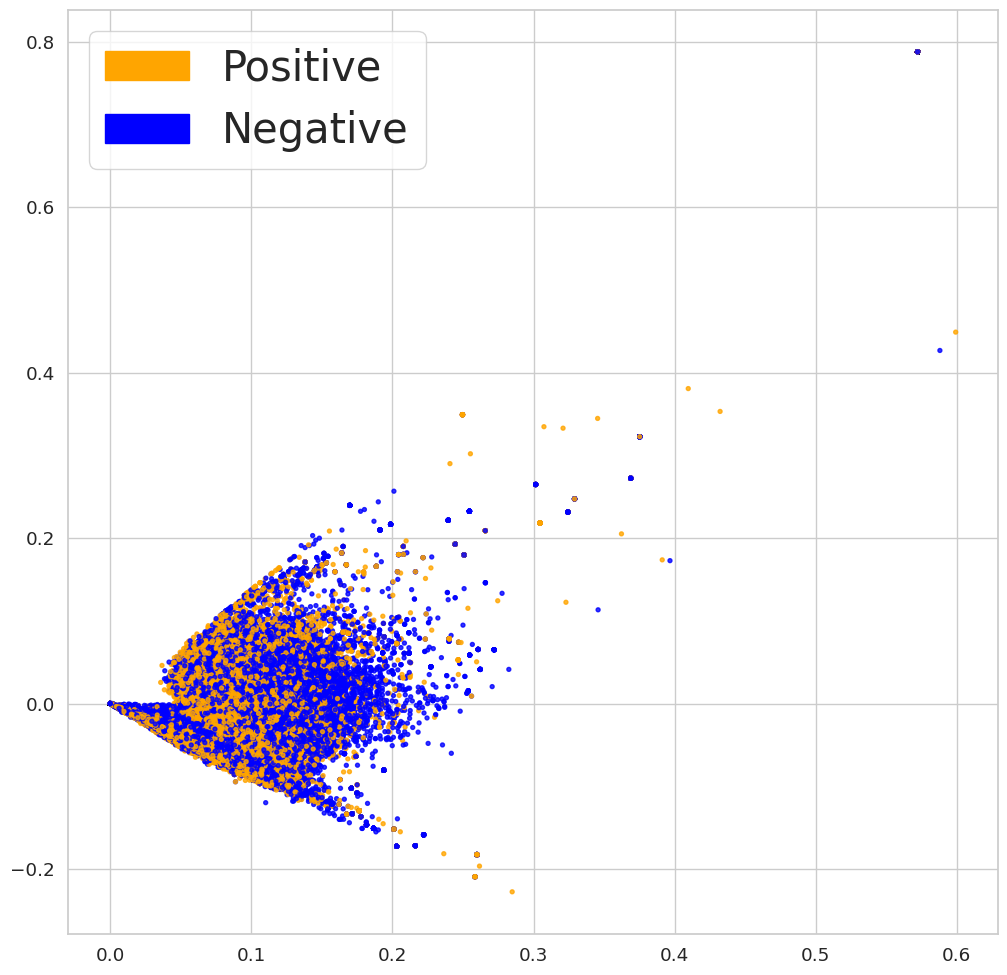

In [ ]:
# FYI LSA -> Latent semantic analysis

def plot_LSA(test_data, test_labels):
    lsa = TruncatedSVD(n_components=2)
    lsa.fit(test_data)
    lsa_scores = lsa.transform(test_data)

    colors = ['orange','blue']
    plt.scatter(lsa_scores[:,0], lsa_scores[:,1], s=8, alpha=.8, c=test_labels, cmap=matplotlib.colors.ListedColormap(colors))
    orange_patch = mpatches.Patch(color='orange', label='Positive')
    blue_patch = mpatches.Patch(color='blue', label='Negative')
    plt.legend(handles=[orange_patch, blue_patch], prop={'size': 30})

fig = plt.figure(figsize=(12, 12))
plot_LSA(X_train_tfv, y_train)
plt.show()

**Count Features**

In [ ]:
%%time
ctv = CountVectorizer(analyzer='word',token_pattern=r'\w{1,}',
            ngram_range=(1, 3), stop_words = 'english')

# Fitting Count Vectorizer to both training and test sets (semi-supervised learning)
ctv.fit(list(train_reviews) + list(test_reviews))

X_train_ctv=  ctv.transform(train_reviews)
X_test_ctv = ctv.transform(test_reviews)

CPU times: user 51.4 s, sys: 1.15 s, total: 52.6 s
Wall time: 53 s


LSA Plot

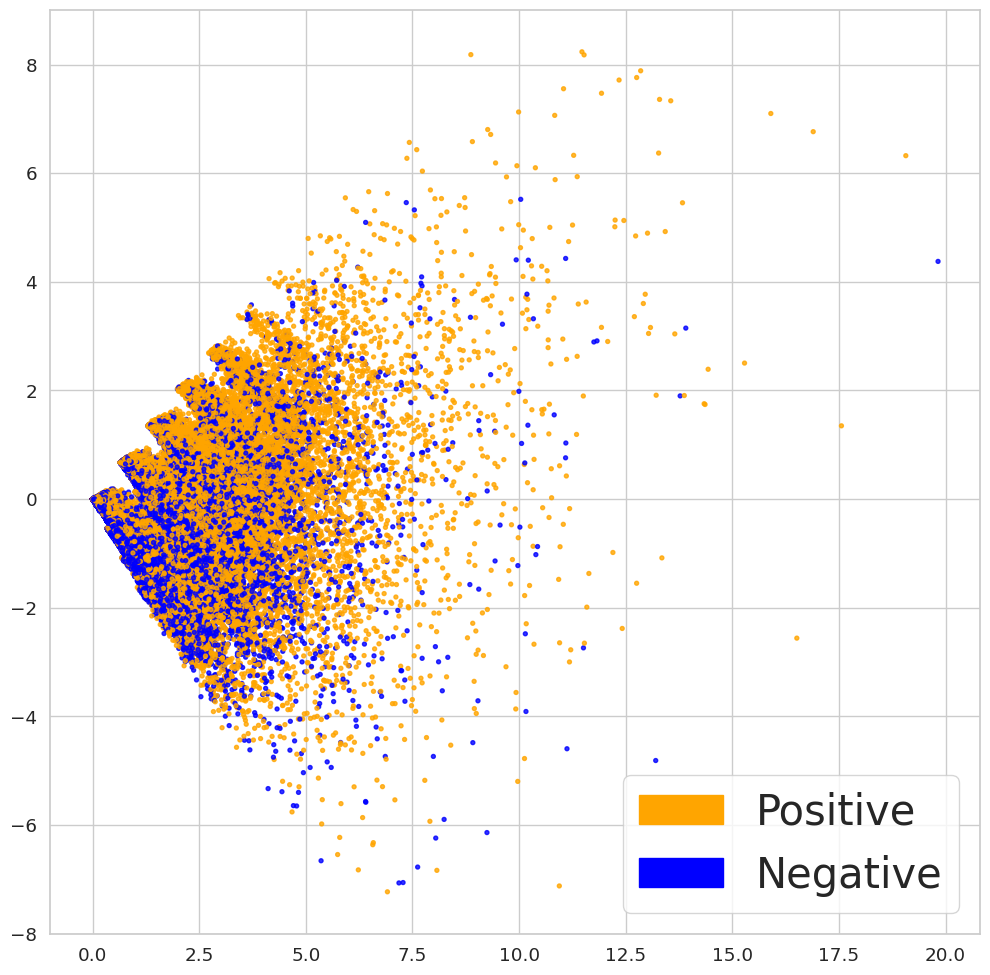

In [ ]:
fig=plt.figure(figsize=(12, 12))
plot_LSA(X_train_ctv, y_train)
plt.show()

**Logistic Regression**

Utility Function

In [ ]:
def model_predict(clf, X_train,y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    predictions = clf.predict_proba(X_test)

    print (f"logloss: {metrics.log_loss(y_test, predictions):0.3f}")
    print (f"ROC AUC: {metrics.roc_auc_score(y_test, predictions[:, 1]):0.3f}")

In [ ]:
%%time

clf = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)

# count vector feature
model_predict(clf, X_train_ctv,y_train, X_test_ctv, y_test)

logloss: 0.456
ROC AUC: 0.894
CPU times: user 2min 27s, sys: 19.2 s, total: 2min 46s
Wall time: 1min 56s


In [ ]:
%%time

# Tf-IDF feature
model_predict(clf, X_train_tfv,y_train, X_test_tfv, y_test)

logloss: 0.403
ROC AUC: 0.900
CPU times: user 14.4 s, sys: 3.16 s, total: 17.5 s
Wall time: 10.7 s


**Naive Bayes**

In [ ]:
%%time
clf = MultinomialNB()

# Tf-IDF feature
model_predict(clf, X_train_tfv, y_train, X_test_tfv, y_test)

logloss: 0.414
ROC AUC: 0.892
CPU times: user 269 ms, sys: 0 ns, total: 269 ms
Wall time: 299 ms


In [ ]:
%%time

# count vector feature
model_predict(clf, X_train_ctv, y_train, X_test_ctv, y_test)

logloss: 1.248
ROC AUC: 0.877
CPU times: user 641 ms, sys: 159 ms, total: 801 ms
Wall time: 902 ms


**SVM**

In [ ]:
# svd = decomposition.TruncatedSVD(n_components=120) # 120-200 is a good range
# svd.fit(X_train_tfv)
# X_train_svd = svd.transform(X_train_tfv)
# X_test_svd = svd.transform(X_test_tfv)
# #
# scl = preprocessing.StandardScaler()
# scl.fit(X_train_svd)
# X_train_svd_scl = scl.transform(X_train_svd)
# X_test_svd_scl = scl.transform(X_test_svd)

In [ ]:
%%time

# it never ends :v

# clf = SVC(C=1.0, probability=True) # since we need probabilities

# model_predict(clf, X_train_svd_scl, y_train, X_test_svd_scl, y_test)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 10.5 µs


**XGBoost**

In [ ]:
%%time
clf = xgb.XGBClassifier(max_depth=7, n_estimators=200, colsample_bytree=0.8,
#                         tree_method='gpu_hist', gpu_id=0,
                        use_label_encoder=False,
                        subsample=0.8, nthread=10, learning_rate=0.01)
model_predict(clf, X_train_tfv, y_train, X_test_tfv, y_test)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[14:37:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




logloss: 0.560
ROC AUC: 0.818
CPU times: user 23min 11s, sys: 9.47 s, total: 23min 21s
Wall time: 15min 52s


In [ ]:
%%time
model_predict(clf, X_train_ctv, y_train, X_test_ctv, y_test)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning:

[15:02:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




logloss: 0.561
ROC AUC: 0.817
CPU times: user 1h 20min 31s, sys: 18.5 s, total: 1h 20min 50s
Wall time: 51min 25s
